<center>


<div style="display: flex; justify-content: center;">
    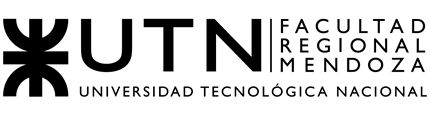
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Ingeniería en Electrónica</strong></p>
        <p><strong>Ingeniería en Telecomunicaciones</strong></p>
    </div>
</center>

# Módulo 7 — NumPy

Hasta acá trabajaste con listas, tuplas y números sueltos. Eso alcanza para problemas chicos, pero cuando una señal tiene **miles** de muestras hacer un `for` sobre una lista se vuelve lento y verboso. Lo que sigue es la herramienta que cambia ese juego: **NumPy**.

NumPy es la librería estándar de Python para trabajar con **arreglos numéricos** de forma eficiente. Prácticamente todo el ecosistema científico de Python — Matplotlib, SciPy, pandas, las librerías de inteligencia artificial — usa NumPy por debajo. Dominarla es **condición necesaria** para todo el contenido que trabajaremos.

La idea central es simple: un *array* de NumPy es parecido a una lista, pero con dos ventajas enormes:

1. **Operaciones vectorizadas**: podés sumar, multiplicar o aplicar funciones a todo un array de una sola vez, sin escribir un `for`.
2. **Velocidad**: por dentro NumPy usa código compilado en C, varias veces más rápido que un bucle en Python puro.

Los temas de este módulo son:

| Tema | Para qué sirve |
|------|----------------|
| `import numpy as np` | Cargar la librería con su alias convencional |
| `np.array` | Crear un array a partir de una lista |
| `np.zeros`, `np.ones` | Arrays rellenos |
| `np.arange`, `np.linspace` | Arrays con secuencias de valores |
| Operaciones vectorizadas | Aritmética sobre arrays completos sin bucles |
| Funciones matemáticas | `np.sin`, `np.cos`, `np.exp`, `np.sqrt`, `np.log`, `np.abs` |
| Indexado y slicing | Seleccionar elementos o tramos de un array |
| Agregación | `sum`, `mean`, `std`, `min`, `max` sobre arrays |

> **Conexión con el Módulo 6.** Un array de NumPy es un **objeto** (tipo `ndarray`): tiene atributos como `.shape` (la forma) y métodos como `.mean()` (el promedio). Todo lo que aprendiste sobre atributos y métodos se aplica tal cual.

## 1. Cargar la librería

En el Módulo 5 vimos que para usar funciones de `math` escribíamos algo como

```python
from math import sin, pi
```

Con NumPy se usa una forma distinta, que carga **toda** la librería de una vez y le asigna un alias corto:

In [1]:
import numpy as np

A partir de ahora, cada vez que escribamos `np.algo` le estamos pidiendo a NumPy una de sus funciones, constantes o tipos. El alias `np` es una **convención universal** en Python: vas a ver ese mismo `import` en prácticamente todo código que leas.

> **Ejecutá esta celda una sola vez** al abrir el notebook. De ahí en adelante, `np` queda disponible hasta que reinicies el entorno.

## 2. El primer array

La forma más directa de crear un array es a partir de una lista:

In [2]:
tensiones = np.array([0.5, 1.2, 3.3, 5.0, 12.0])
print(tensiones)
print(type(tensiones))

[ 0.5  1.2  3.3  5.  12. ]
<class 'numpy.ndarray'>


Tres observaciones:

- Lo que vemos por pantalla se parece a una lista, pero **no lo es**: el tipo es `numpy.ndarray`.
- A diferencia de una lista, todos los elementos deben ser del **mismo tipo** (típicamente todos `float` o todos `int`). NumPy elige uno y lo aplica a todo el array.
- Un `ndarray` es un objeto, con sus propios atributos y métodos. Veamos tres atributos útiles:

In [3]:
print("shape:", tensiones.shape)   # forma del array (tupla)
print("size: ", tensiones.size)    # cantidad total de elementos
print("dtype:", tensiones.dtype)   # tipo de los elementos

shape: (5,)
size:  5
dtype: float64


- `shape` devuelve una tupla con las dimensiones. Para un array 1D como `tensiones`, la tupla tiene un solo número: `(5,)` significa "cinco elementos en una única dimensión".
- `size` es simplemente la cantidad de elementos.
- `dtype` es el tipo de los elementos. `float64` es el tipo numérico más común: un número de punto flotante de 64 bits.

### Arrays de más de una dimensión

También se puede armar un array bidimensional pasando una lista de listas:

In [4]:
matriz = np.array([[1, 2, 3],
                   [4, 5, 6]])

print(matriz)
print("shape:", matriz.shape)

[[1 2 3]
 [4 5 6]]
shape: (2, 3)


El `shape` acá es `(2, 3)`: dos filas y tres columnas. En el curso vamos a trabajar casi siempre con arrays **1D** (señales en el tiempo), así que no vamos a profundizar en 2D por ahora. Aparecerán de forma natural cuando, en algún laboratorio, guardemos varias señales juntas.

## 3. Crear arrays sin escribir sus valores

Escribir a mano cada elemento no escala: necesitamos formas de **generar** arrays con patrones conocidos.

### 3.1. `np.zeros` y `np.ones`

Crean arrays rellenos de ceros o unos:

In [5]:
ceros = np.zeros(8)        # 8 ceros
unos = np.ones(5)          # 5 unos

print("ceros:", ceros)
print("unos: ", unos)

ceros: [0. 0. 0. 0. 0. 0. 0. 0.]
unos:  [1. 1. 1. 1. 1.]


Son útiles para **reservar** un array que después se completa con resultados, o para representar señales constantes (por ejemplo, una señal en reposo).

### 3.2. `np.arange`

Genera valores en un rango con un **paso fijo**, igual que `range()` de Python pero devolviendo un array y admitiendo pasos no enteros:

```python
np.arange(inicio, fin, paso)
```

El valor `fin` **no se incluye** (igual que en `range`).

In [6]:
print(np.arange(10))           # 0, 1, 2, ..., 9
print(np.arange(2, 10, 2))     # 2, 4, 6, 8
print(np.arange(0, 1, 0.1))    # 0.0, 0.1, 0.2, ..., 0.9

[0 1 2 3 4 5 6 7 8 9]
[2 4 6 8]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


### 3.3. `np.linspace`

Muchas veces no queremos fijar un paso, sino una **cantidad** de puntos equiespaciados entre dos extremos. Para eso se usa `linspace`:

```python
np.linspace(inicio, fin, cantidad)
```

A diferencia de `arange`, acá `fin` **sí se incluye** y lo que fijamos es el número total de puntos.

In [7]:
print(np.linspace(0, 1, 5))    # 5 puntos entre 0 y 1 inclusive
print(np.linspace(0, 10, 11))  # 11 puntos entre 0 y 10 inclusive

[0.   0.25 0.5  0.75 1.  ]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


### Cuándo usar cada una

| Necesitás... | Usá |
|--------------|-----|
| Una secuencia con **paso** específico (cada 0.1 s, cada 10 muestras) | `np.arange` |
| Una cantidad **exacta** de puntos entre dos extremos (ambos incluidos) | `np.linspace` |

Para generar el **eje de tiempos** de una señal, casi siempre vas a preferir `linspace`: decís "de 0 a 1 segundo, con 1000 puntos" y listo, no hace falta pelearte con el paso.

## 4. Operaciones vectorizadas con un escalar

Acá aparece la magia de NumPy. Si tenés un array y le hacés una operación aritmética con un número, la operación se aplica **a cada elemento**, sin escribir ningún `for`:

In [8]:
v = np.array([1.0, 2.0, 3.0, 4.0, 5.0])

print("v        =", v)
print("v + 10   =", v + 10)
print("v * 2    =", v * 2)
print("v / 4    =", v / 4)
print("v ** 2   =", v ** 2)

v        = [1. 2. 3. 4. 5.]
v + 10   = [11. 12. 13. 14. 15.]
v * 2    = [ 2.  4.  6.  8. 10.]
v / 4    = [0.25 0.5  0.75 1.   1.25]
v ** 2   = [ 1.  4.  9. 16. 25.]


Comparalo con lo que habrías tenido que escribir para hacer lo mismo con una lista común:

```python
v_lista = [1.0, 2.0, 3.0, 4.0, 5.0]
v_mas_10 = [x + 10 for x in v_lista]
```

Con NumPy, `v + 10` hace exactamente eso, pero más corto, más legible y mucho más rápido.

### Actividad 1: ley de Ohm vectorizada

Tenés un banco de resistencias iguales de $R = 220\ \Omega$, y una serie de tensiones medidas a la entrada de cada una.

1. Creá un array `tensiones` con los valores `[1.0, 2.5, 3.3, 5.0, 9.0, 12.0]` volts.
2. Calculá un array `corrientes` con la corriente que circula por cada resistencia según $I = V/R$. Hacelo **en una sola línea**, sin `for`.
3. Mostrá el array `corrientes` en miliamperes (1 A = 1000 mA). Tip: multiplicar el array completo por 1000 funciona tal cual.

In [9]:
import numpy as np

# TU CÓDIGO AQUÍ

## 5. Operaciones entre dos arrays

Si dos arrays tienen la misma forma, las operaciones aritméticas se hacen **elemento a elemento**:

In [10]:
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

print("a + b =", a + b)
print("a * b =", a * b)
print("b - a =", b - a)
print("b / a =", b / a)

a + b = [11 22 33 44]
a * b = [ 10  40  90 160]
b - a = [ 9 18 27 36]
b / a = [10. 10. 10. 10.]


Esto es distinto a lo que hace `+` con listas de Python (que concatena): con arrays de NumPy, `+` siempre suma elemento a elemento.

> **Ojo.** Si los dos arrays tienen **formas diferentes**, NumPy intenta una operación llamada *broadcasting*. Eso lo vamos a ver aparecer de a poco en los laboratorios; por ahora, trabajá siempre con arrays del mismo largo y vas a estar del lado seguro.

## 6. Funciones matemáticas

NumPy trae versiones **vectorizadas** de las funciones matemáticas del módulo `math`: reciben un array y devuelven otro array del mismo tamaño con la función aplicada a cada elemento.

In [11]:
x = np.array([0.0, 0.5, 1.0, 1.5, 2.0])

print("np.sqrt(x) =", np.sqrt(x))
print("np.exp(x)  =", np.exp(x))
print("np.log(x + 1) =", np.log(x + 1))   # log natural
print("np.abs(-x) =", np.abs(-x))

np.sqrt(x) = [0.         0.70710678 1.         1.22474487 1.41421356]
np.exp(x)  = [1.         1.64872127 2.71828183 4.48168907 7.3890561 ]
np.log(x + 1) = [0.         0.40546511 0.69314718 0.91629073 1.09861229]
np.abs(-x) = [0.  0.5 1.  1.5 2. ]


Las funciones trigonométricas esperan el argumento en **radianes** (igual que `math.sin`):

In [12]:
angulos = np.array([0, np.pi/4, np.pi/2, np.pi])

print("np.sin =", np.sin(angulos))
print("np.cos =", np.cos(angulos))

np.sin = [0.00000000e+00 7.07106781e-01 1.00000000e+00 1.22464680e-16]
np.cos = [ 1.00000000e+00  7.07106781e-01  6.12323400e-17 -1.00000000e+00]


### Constantes útiles

NumPy incluye las constantes matemáticas básicas:

In [13]:
print("np.pi =", np.pi)
print("np.e  =", np.e)

np.pi = 3.141592653589793
np.e  = 2.718281828459045


De ahora en adelante, en lugar de `from math import pi, sin` vas a preferir usar `np.pi` y `np.sin` directamente: sirven para arrays y para números sueltos por igual.

### Actividad 2: muestrear una señal senoidal

En el Módulo 6 construiste una señal senoidal elemento por elemento con un `for`. Ahora lo vas a hacer **en dos líneas** con NumPy.

Querés muestrear la señal

$$x(t) = A \sin(2\pi f t)$$

con amplitud $A = 2$ V, frecuencia $f = 100$ Hz, durante 20 ms.

1. Generá un array `t` con `linspace`: 200 puntos equiespaciados entre 0 y 0.02 segundos.
2. Calculá el array `x` aplicando la fórmula de la senoidal a `t`. Una sola línea, sin bucles.
3. Mostrá el `shape` de `x` (debería ser `(200,)`) y los primeros 5 valores (vamos a ver cómo más abajo, pero como adelanto: `x[:5]`).

In [14]:
import numpy as np

# TU CÓDIGO AQUÍ

## 7. Indexado y *slicing*

Acceder a elementos de un array es igual que en las listas del Módulo 3: índice entre corchetes, contando desde 0.

In [15]:
señal = np.array([0.0, 0.3, 0.6, 0.9, 0.6, 0.3, 0.0, -0.3, -0.6, -0.9])

print("primer elemento:", señal[0])
print("último:         ", señal[-1])     # índice negativo: cuenta desde el final
print("cuarto:         ", señal[3])

primer elemento: 0.0
último:          -0.9
cuarto:          0.9


### Slicing

La sintaxis `array[inicio:fin:paso]` extrae un tramo del array, igual que con listas. `inicio` se incluye; `fin` se excluye; `paso` es opcional.

In [16]:
print("señal[:4]       →", señal[:4])       # primeros 4 elementos
print("señal[4:]       →", señal[4:])       # desde el índice 4 hasta el final
print("señal[2:6]      →", señal[2:6])      # del índice 2 al 5
print("señal[::2]      →", señal[::2])      # uno de cada dos
print("señal[::-1]     →", señal[::-1])     # array al revés

señal[:4]       → [0.  0.3 0.6 0.9]
señal[4:]       → [ 0.6  0.3  0.  -0.3 -0.6 -0.9]
señal[2:6]      → [0.6 0.9 0.6 0.3]
señal[::2]      → [ 0.   0.6  0.6  0.  -0.6]
señal[::-1]     → [-0.9 -0.6 -0.3  0.   0.3  0.6  0.9  0.6  0.3  0. ]


> **Nota breve: vistas vs. copias.** Un *slice* de un array de NumPy comparte memoria con el original (es una *vista*): si modificás una posición de la vista, se modifica también el array original. Si necesitás un array independiente, usá `señal[2:6].copy()`. Por ahora no te preocupes por este detalle; aparecerá cuando lo necesitemos.

### Actividad 3: recortar los primeros 5 ms

Partiendo del ejercicio anterior:

1. Generá `t = np.linspace(0, 0.02, 200)` (20 ms, 200 puntos).
2. Generá `x` con la misma senoidal de la actividad 2 ($A = 2$, $f = 100$ Hz).
3. Usando slicing, construí dos nuevos arrays `t_corto` y `x_corto` que contengan solo los primeros 5 ms de la señal (es decir, los primeros 50 puntos).
4. Mostrá `t_corto.shape` y `x_corto.shape`, y el **último** valor de `t_corto` para confirmar que terminás cerca de los 5 ms.

In [17]:
import numpy as np

# TU CÓDIGO AQUÍ

## 8. Agregación: reducir un array a un número

Muchas veces querés un **único número** que resuma un array: su promedio, su máximo, la suma de todos los elementos. Para eso NumPy ofrece funciones de agregación:

In [18]:
muestras = np.array([1.0, 2.0, 3.0, 4.0, 5.0])

print("suma:     ", np.sum(muestras))
print("promedio: ", np.mean(muestras))
print("mínimo:   ", np.min(muestras))
print("máximo:   ", np.max(muestras))
print("desv. est:", np.std(muestras))

suma:      15.0
promedio:  3.0
mínimo:    1.0
máximo:    5.0
desv. est: 1.4142135623730951


### Misma operación, dos sintaxis

Una cosa interesante: cada una de estas funciones también existe como **método** del array. Son dos formas de escribir lo mismo:

In [19]:
print(np.mean(muestras))     # forma función
print(muestras.mean())       # forma método

3.0
3.0


Las dos devuelven idéntico resultado. Cuál preferir es cuestión de estilo; lo importante es reconocer las dos cuando las leas. Este es exactamente el patrón "objeto con métodos" que viste en el Módulo 6.

### Actividad 4: potencia media de una señal

La **potencia media** de una señal $x(t)$ a lo largo de un intervalo se puede estimar, a partir de sus muestras, como el promedio de los cuadrados:

$$P_{\text{media}} \approx \frac{1}{N}\sum_{k=0}^{N-1} x_k^2$$

Partiendo de nuevo de la senoidal de la actividad 2 ($A = 2$ V, $f = 100$ Hz, 200 muestras en 20 ms):

1. Generá `t` y `x` como antes.
2. Calculá un array `x2` con el cuadrado de cada muestra. Recordá que `x ** 2` aplica el cuadrado a todo el array.
3. Calculá la potencia media usando `np.mean`. Guardala en `P_media`.
4. Mostrala con tres decimales. Para una senoidal de amplitud $A$, el valor teórico es $A^2/2 = 2$. Tu resultado numérico debería quedar **muy cerca** de 2.

In [20]:
import numpy as np

# TU CÓDIGO AQUÍ

## 9. Un ejemplo de telecomunicaciones

Una aplicación directa: cada emisora de FM usa una **portadora** a una frecuencia distinta, y a cada frecuencia le corresponde una longitud de onda

$$\lambda = \frac{c}{f}$$

donde $c \approx 3 \times 10^{8}$ m/s es la velocidad de la luz. En lugar de calcular una longitud de onda a la vez, podemos calcular todas juntas con un solo array.

In [21]:
c = 3e8   # velocidad de la luz, m/s

# Frecuencias en Hz de cuatro emisoras de FM
frecuencias = np.array([88.1e6, 91.3e6, 95.5e6, 101.7e6])

lambdas = c / frecuencias
print("Longitudes de onda (m):", lambdas)
print("En cm:                 ", lambdas * 100)

Longitudes de onda (m): [3.40522134 3.28587076 3.14136126 2.94985251]
En cm:                  [340.52213394 328.58707558 314.13612565 294.98525074]


Fijate el poder expresivo: `c / frecuencias` divide el escalar `c` por cada elemento del array, sin bucles. Y lo mismo pasa cuando después multiplicamos por 100 para pasar a centímetros.

### Actividad 5: canales de la banda ciudadana

La banda ciudadana (*CB*) de 27 MHz tiene 40 canales. En un pedazo de esa banda, cuatro canales consecutivos están a las frecuencias `[27.005e6, 27.015e6, 27.025e6, 27.035e6]` Hz.

1. Creá el array `frecuencias` con esos cuatro valores.
2. Calculá el array `lambdas` con la longitud de onda de cada canal, en metros. Usá $c = 3 \times 10^{8}$ m/s.
3. Calculá el array `lambdas_4` con la longitud de una **antena de cuarto de onda** ($\lambda/4$) para cada canal, en centímetros.
4. Mostrá `lambdas_4` con dos decimales. Tip: podés armar el texto con `np.round(lambdas_4, 2)` para redondear antes de imprimir.

In [22]:
import numpy as np

# TU CÓDIGO AQUÍ

## Cierre

En este módulo diste el salto de "una operación, un número" a "una operación, miles de números":

- `np.array` convierte una lista en un `ndarray`; `np.zeros`, `np.ones`, `np.arange` y `np.linspace` generan arrays desde cero.
- Las operaciones aritméticas y las funciones matemáticas (`np.sin`, `np.exp`, `np.sqrt`, ...) se aplican **elemento a elemento**, sin bucles.
- El slicing funciona igual que en listas: `array[inicio:fin:paso]` extrae un tramo.
- Las funciones de agregación (`np.mean`, `np.sum`, `np.std`, `np.min`, `np.max`) reducen un array a un número. Muchas existen también como métodos del array: `arr.mean()`.

Con esto ya podés **generar** y **manipular** señales muestreadas de forma compacta. Lo que todavía te falta es **visualizarlas**: mostrar una señal como un gráfico vale más que mil prints. De eso se encarga **Matplotlib**, el tema del próximo módulo.

> **Para explorar más:** la documentación oficial de NumPy está en [numpy.org/doc](https://numpy.org/doc/stable/). Cuando necesites algo específico (generar ruido, calcular percentiles, resolver sistemas lineales), casi seguro que NumPy ya lo tiene.